# BISINDO 24-Kelas **v10** — Training (MobileNetV2 + TSM + CBAM)

**Ablasi vs v9:** HANYA augmentasi pencahayaan/warna yang diperkuat. Semua yang
lain (dataset tersegmentasi, augmentasi **spasial**, arsitektur, epoch, split,
seed) TETAP identik dgn v9 — agar klaim *"augmentasi cahaya membantu kamera
real-time"* terukur dgn **1 variabel berubah** (jujur untuk tabel ablasi Bab 4).

**Motivasi:** model v9 test 97,78% tapi flat di kamera baru → domain gap cahaya
(kamera lebih gelap/terang/semburat warna lampu).

| Aspek | v9 | v10 |
|---|---|---|
| brightness | 0.8–1.2 | **0.6–1.4** |
| contrast | 0.8–1.2 | **0.6–1.4** |
| saturation | 0.9–1.1 | **0.8–1.2** |
| hue | ±0.05 | **±0.08** |
| gamma | — | **0.7–1.5 (baru)** |
| spasial / arsitektur / epoch / split | — | **TETAP** |

> Jalankan sel **berurutan dari atas**. Sel yang paling sering diedit untuk
> eksperimen pencahayaan ada di bagian **"Augmentasi (v10)"**.

## 1. Import & setup

In [1]:
import os, re, random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models.mobilenetv2 import InvertedResidual
import torchvision.transforms.functional as TF
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from collections import Counter, defaultdict

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

## 2. Konfigurasi & path
Dataset **SAMA** dgn v9 (`WLBISINDO_seg`) — output ke folder v10.

In [3]:
# ── Path (sesuaikan di laptop GPU) ──
DATASET_PATH = '/home/muji/skripsi_bisindo24/WLBISINDO_seg'
SAVE_DIR     = '/home/muji/skripsi_bisindo24/v10_lighting'
os.makedirs(SAVE_DIR, exist_ok=True)

CKPT_S1 = os.path.join(SAVE_DIR, 'best_stage1_v10.pth')
CKPT_S2 = os.path.join(SAVE_DIR, 'best_stage2_v10.pth')

EXPLICIT_CLASSES = [
    'air', 'bagaimana', 'belajar', 'berangkat', 'cari',
    'datang', 'dengar', 'dimana', 'hijau', 'merah',
    'kapan', 'keluarga', 'kuning', 'lagi', 'maaf',
    'makan', 'mengapa', 'motor', 'rumah', 'saya',
    'siapa', 'teman', 'terimakasih', 'tuli'
]

NUM_CLASSES           = 24
NUM_FRAMES            = 16
IMG_SIZE              = (224, 224)
MARGIN                = 0.15          # sinkron dgn inference
BATCH_SIZE            = 8
EPOCH_STAGE1          = 12
EPOCH_STAGE2          = 45
LR_STAGE1             = 1e-3
LR_STAGE2             = 1e-4
WEIGHT_DECAY          = 1e-3
EARLY_STOP_PATIENCE   = 7
LR_SCHEDULER_FACTOR   = 0.5
LR_SCHEDULER_PATIENCE = 3
LABEL_SMOOTHING       = 0.1
DROPOUT               = 0.5
NUM_WORKERS           = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | Dataset: {DATASET_PATH}')

Device: cuda | Dataset: /home/muji/skripsi_bisindo24/WLBISINDO_seg


## 3. Data loading & frame extraction

In [4]:
def parse_signer(filename):
    name = os.path.basename(filename).lower()
    m = re.search(r'signer(\d+)', name)
    if m: return int(m.group(1))
    m = re.search(r'(?:^|[^a-z])s(\d+)[_\-]', name)
    if m: return int(m.group(1))
    return -1


def load_dataset(dataset_path, classes):
    video_files, labels, signers = [], [], []
    for label, class_name in enumerate(classes):
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            print(f'  [WARN] folder kelas tidak ada: {class_name}')
            continue
        for vname in sorted(os.listdir(class_path)):
            if vname.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                video_files.append(os.path.join(class_path, vname))
                labels.append(label)
                signers.append(parse_signer(vname))
    print(f'Loaded {len(video_files)} video dari {len(classes)} kelas')
    return video_files, labels, signers

In [5]:
def extract_frames(video_path, num_frames, img_size=(224, 224),
                   is_train=False, margin=MARGIN):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return [np.zeros((img_size[1], img_size[0], 3), dtype=np.uint8)] * num_frames

    total = max(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), 1)
    start_frame = int(total * margin)
    end_frame   = int(total * (1.0 - margin))
    valid_total = max(end_frame - start_frame, 1)
    seg_size    = valid_total / float(num_frames)

    indices = []
    for i in range(num_frames):
        s = int(start_frame + i * seg_size)
        e = int(start_frame + (i + 1) * seg_size)
        if is_train and e > s:
            idx = np.random.randint(s, e)
        else:
            idx = s + (e - s) // 2
        indices.append(min(idx, total - 1))

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, img_size)
            frames.append(frame)
        else:
            frames.append(frames[-1] if frames else
                          np.zeros((img_size[1], img_size[0], 3), dtype=np.uint8))
    cap.release()
    while len(frames) < num_frames:
        frames.append(frames[-1])
    return frames[:num_frames]

## 4. Augmentasi (v10) — **SEL UTAMA untuk eksperimen pencahayaan**

Spasial **TETAP** spt v9. Fotometrik diperkuat + gamma jitter (baru). Untuk
memiringkan ke arah gelap (kalau kamera target gelap), ubah `b`/`g` di sini,
mis. `b = random.uniform(0.5, 1.1)` dan `g = random.uniform(0.8, 1.8)`.

In [6]:
class ConsistentVideoAugment:
    def __init__(self, train=True, img_size=224):
        self.train = train
        self.img_size = img_size

    def __call__(self, frames_bgr):
        T = len(frames_bgr)
        W = self.img_size

        if self.train:
            # Spasial: TETAP spt v9 — posisi/arah tangan = makna isyarat
            angle     = random.uniform(-7, 7)
            translate = (random.uniform(-0.07, 0.07) * W,
                         random.uniform(-0.07, 0.07) * W)
            scale     = random.uniform(0.88, 1.12)
            # Fotometrik DIPERLEBAR (v10) — robust thd kamera gelap/terang/warna lampu
            b = random.uniform(0.6, 1.4)     # v9: 0.8-1.2
            c = random.uniform(0.6, 1.4)     # v9: 0.8-1.2
            s = random.uniform(0.8, 1.2)     # v9: 0.9-1.1
            h = random.uniform(-0.08, 0.08)  # v9: +-0.05
            g = random.uniform(0.7, 1.5)     # v10 BARU: gamma jitter

        out = []
        for t in range(T):
            rgb_np = cv2.cvtColor(frames_bgr[t], cv2.COLOR_BGR2RGB)
            pil = Image.fromarray(rgb_np)
            if self.train:
                pil = TF.affine(pil, angle=angle, translate=list(translate),
                                scale=scale, shear=[0.0, 0.0])
                pil = TF.adjust_brightness(pil, b)
                pil = TF.adjust_contrast(pil, c)
                pil = TF.adjust_saturation(pil, s)
                pil = TF.adjust_hue(pil, h)
                pil = TF.adjust_gamma(pil, g)            # v10: simulasi respons cahaya kamera
            tens = TF.to_tensor(pil)
            tens = TF.normalize(tens, IMAGENET_MEAN, IMAGENET_STD)
            out.append(tens)
        return torch.stack(out)   # (T, 3, H, W)

In [7]:
class VideoDataset(Dataset):
    def __init__(self, video_files, labels, signers, augmentor,
                 num_frames=16, is_train=False):
        self.video_files = video_files
        self.labels      = labels
        self.signers     = signers
        self.augmentor   = augmentor
        self.num_frames  = num_frames
        self.is_train    = is_train

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, idx):
        frames = extract_frames(self.video_files[idx], self.num_frames,
                                is_train=self.is_train)
        video = self.augmentor(frames)
        return video, self.labels[idx], self.signers[idx]

## 5. Model — TSM + CBAM + MobileNetV2 (identik v9 → checkpoint kompatibel)

In [8]:
class TemporalShift(nn.Module):
    def __init__(self, n_segment=16, n_div=8):
        super().__init__()
        self.n_segment = n_segment
        self.fold_div  = n_div

    def forward(self, x):
        BT, C, H, W = x.size()
        B = BT // self.n_segment
        x = x.view(B, self.n_segment, C, H, W)
        fold = C // self.fold_div
        out = torch.zeros_like(x)              # boundary -> 0 (sama dgn inference)
        out[:, 1:,    :fold]      = x[:, :-1, :fold]
        out[:, :-1, fold:2*fold]  = x[:, 1:,  fold:2*fold]
        out[:, :,   2*fold:]      = x[:, :,   2*fold:]
        return out.view(BT, C, H, W)


def inject_tsm(model, n_segment=16, n_div=8):
    count = 0
    for block in model.features:
        if isinstance(block, InvertedResidual):
            orig = block.conv[0]
            block.conv[0] = nn.Sequential(TemporalShift(n_segment, n_div), orig)
            count += 1
    print(f'  TSM injected ke {count} InvertedResidual blocks')
    return model

In [9]:
class ChannelAttention(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.mx  = nn.AdaptiveMaxPool2d(1)
        self.fc  = nn.Sequential(nn.Linear(ch, ch//r, bias=False), nn.ReLU(),
                                  nn.Linear(ch//r, ch, bias=False))
        self.sig = nn.Sigmoid()

    def forward(self, x):
        B, C, H, W = x.size()
        a = self.fc(self.avg(x).view(B, C))
        m = self.fc(self.mx(x).view(B, C))
        return x * self.sig(a + m).view(B, C, 1, 1)


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sig  = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1, keepdim=True).values
        return x * self.sig(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.channel_att = ChannelAttention(ch, r)
        self.spatial_att = SpatialAttention()

    def forward(self, x):
        return self.spatial_att(self.channel_att(x))

In [10]:
class BISINDOClassifier(nn.Module):
    def __init__(self, num_classes, num_frames=16, use_cbam=True,
                 grid=4, reduce_dim=256, dropout=0.5):
        super().__init__()
        self.num_frames = num_frames
        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        backbone = inject_tsm(backbone, n_segment=num_frames, n_div=8)
        self.features = backbone.features
        feat_dim      = backbone.last_channel   # 1280

        self.cbam   = CBAM(feat_dim) if use_cbam else nn.Identity()
        self.reduce = nn.Sequential(
            nn.Conv2d(feat_dim, reduce_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(reduce_dim),
            nn.ReLU(inplace=True))
        self.pool        = nn.AdaptiveAvgPool2d((grid, grid))
        self.spatial_dim = reduce_dim * grid * grid

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.spatial_dim, num_classes))

    def forward(self, x):   # (B, T, 3, H, W)
        B, T, C, H, W = x.size()
        x = x.view(B * T, C, H, W)
        x = self.features(x)
        x = self.cbam(x)
        x = self.reduce(x)
        x = self.pool(x).view(B, T, -1)
        x = x.mean(dim=1)
        return self.classifier(x)


def freeze_backbone(model):
    for p in model.features.parameters():
        p.requires_grad = False
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  [Stage 1] Backbone frozen - trainable: {n:,}')


def unfreeze_partial(model, from_layer=14):
    for p in model.features.parameters():
        p.requires_grad = False
    for layer in list(model.features.children())[from_layer:]:
        for p in layer.parameters():
            p.requires_grad = True
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  [Stage 2] Unfreeze from layer {from_layer} - trainable: {n:,}')

## 6. Utilitas training (EarlyStopping, loop, plot)

In [11]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4, path='best.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best_loss = float('inf')
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            print(f'    [v] Val loss {val_loss:.4f} membaik - checkpoint disimpan')
        else:
            self.counter += 1
            print(f'    [-] Tidak ada peningkatan ({self.counter}/{self.patience})')
            if self.counter >= self.patience:
                self.stop = True
                model.load_state_dict(torch.load(self.path, map_location=device))
                print(f'    [x] Early stop. Bobot terbaik dimuat.')

In [12]:
def run_epoch(model, loader, criterion, optimizer=None, is_train=True, desc=''):
    model.train() if is_train else model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    per_signer_correct = defaultdict(int)
    per_signer_total   = defaultdict(int)

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for inputs, labels_batch, signers_batch in tqdm(loader, desc=desc, leave=False):
            inputs = inputs.to(device, non_blocking=True)
            labels_batch = labels_batch.to(device, non_blocking=True)
            if is_train:
                optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels_batch)
            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            with torch.no_grad():
                preds = outputs.argmax(dim=1)
                correct = (preds == labels_batch)
                total_loss    += loss.item() * inputs.size(0)
                total_correct += correct.sum().item()
                total_n       += inputs.size(0)
                for sig, ok in zip(signers_batch.tolist(), correct.cpu().tolist()):
                    per_signer_total[sig]   += 1
                    per_signer_correct[sig] += int(ok)

    per_signer_acc = {s: per_signer_correct[s] / per_signer_total[s]
                      for s in per_signer_total}
    return total_loss / total_n, total_correct / total_n, per_signer_acc

In [13]:
def train_model(model, criterion, train_loader, val_loader, num_epochs,
                optimizer, scheduler=None, early_stopping=None, stage_name=''):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'val_per_signer': [], 'lr': []}
    for ep in range(1, num_epochs + 1):
        t_loss, t_acc, _ = run_epoch(model, train_loader, criterion, optimizer,
                                     is_train=True, desc=f'{stage_name} E{ep:02d} Train')
        v_loss, v_acc, v_sig = run_epoch(model, val_loader, criterion, None,
                                         is_train=False, desc=f'{stage_name} E{ep:02d} Val')
        lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(t_loss); history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss);   history['val_acc'].append(v_acc)
        history['val_per_signer'].append(v_sig); history['lr'].append(lr)

        v_sig_str = ' | '.join(f's{s}:{a:.2f}' for s, a in sorted(v_sig.items()))
        print(f'[{stage_name}] Ep {ep:02d} | Train L={t_loss:.4f} A={t_acc:.4f} | '
              f'Val L={v_loss:.4f} A={v_acc:.4f} | {v_sig_str} | LR={lr:.2e}')

        if scheduler:
            scheduler.step(v_loss)
        if early_stopping:
            early_stopping(v_loss, model)
            if early_stopping.stop:
                print(f'  Stopped at epoch {ep}/{num_epochs}')
                break
    return history

In [14]:
def plot_history(h1, h2, save_path):
    s1, s2 = len(h1['train_loss']), len(h2['train_loss'])
    if s1 + s2 == 0:
        print('[Plot] Tidak ada data.'); return
    eps = list(range(1, s1 + s2 + 1))
    tl = h1['train_loss'] + h2['train_loss']; vl = h1['val_loss'] + h2['val_loss']
    ta = h1['train_acc']  + h2['train_acc'];  va = h1['val_acc']  + h2['val_acc']
    fig, (axL, axA) = plt.subplots(1, 2, figsize=(14, 5))
    axL.plot(eps, tl, label='Train'); axL.plot(eps, vl, label='Val')
    axL.axvline(s1 + 0.5, color='red', ls='--', label='S1->S2')
    axL.set(title='Loss', xlabel='Epoch'); axL.legend(); axL.grid(alpha=0.3)
    axA.plot(eps, ta, label='Train'); axA.plot(eps, va, label='Val')
    axA.axvline(s1 + 0.5, color='red', ls='--')
    axA.set(title='Accuracy', xlabel='Epoch'); axA.legend(); axA.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=140, bbox_inches='tight')
    plt.show()
    print(f'[Plot] Saved: {save_path}')

## 7. Eksekusi — Load dataset + split 70:15:15

In [15]:
video_files, labels, signers = load_dataset(DATASET_PATH, EXPLICIT_CLASSES)
assert len(video_files) > 0, 'Tidak ada video. Pastikan preprocess_segment.py sudah jalan.'

train_idx, temp_idx = train_test_split(
    range(len(video_files)), test_size=0.30, random_state=SEED, stratify=labels)
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED, stratify=temp_labels)

def pick(idxs):
    return ([video_files[i] for i in idxs],
            [labels[i] for i in idxs],
            [signers[i] for i in idxs])

train_vf, train_lb, train_sg = pick(train_idx)
val_vf,   val_lb,   val_sg   = pick(val_idx)
test_vf,  test_lb,  test_sg  = pick(test_idx)
print(f'Split -> Train {len(train_vf)} | Val {len(val_vf)} | Test {len(test_vf)}')

assert not (set(train_vf) & set(val_vf)) and not (set(train_vf) & set(test_vf)) \
    and not (set(val_vf) & set(test_vf)), 'LEAKAGE: video overlap antar split'

Loaded 1200 video dari 24 kelas
Split -> Train 840 | Val 180 | Test 180


In [16]:
train_aug = ConsistentVideoAugment(train=True)
eval_aug  = ConsistentVideoAugment(train=False)
train_ds = VideoDataset(train_vf, train_lb, train_sg, train_aug, NUM_FRAMES, is_train=True)
val_ds   = VideoDataset(val_vf,   val_lb,   val_sg,   eval_aug,  NUM_FRAMES, is_train=False)
test_ds  = VideoDataset(test_vf,  test_lb,  test_sg,  eval_aug,  NUM_FRAMES, is_train=False)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=(NUM_WORKERS > 0))
val_loader   = DataLoader(val_ds, BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=(NUM_WORKERS > 0))
test_loader  = DataLoader(test_ds, BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=(NUM_WORKERS > 0))
print('DataLoader siap.')

DataLoader siap.


## 8. Build model

In [17]:
print('Building model v10...')
model = BISINDOClassifier(NUM_CLASSES, NUM_FRAMES, dropout=DROPOUT).to(device)
print(f'  Total parameter: {sum(p.numel() for p in model.parameters()):,}')
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

Building model v10...
  TSM injected ke 17 InvertedResidual blocks
  Total parameter: 2,855,290


## 9. Stage 1 — Frozen backbone

In [18]:
print('=' * 60 + '\nSTAGE 1 - FROZEN BACKBONE\n' + '=' * 60)
freeze_backbone(model)
opt1 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                   lr=LR_STAGE1, weight_decay=WEIGHT_DECAY)
sch1 = optim.lr_scheduler.ReduceLROnPlateau(opt1, mode='min',
                   factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE)
es1 = EarlyStopping(EARLY_STOP_PATIENCE, path=CKPT_S1)
h1 = train_model(model, criterion, train_loader, val_loader, EPOCH_STAGE1,
                 opt1, sch1, es1, stage_name='S1')

STAGE 1 - FROZEN BACKBONE
  [Stage 1] Backbone frozen - trainable: 631,418


[S1] Ep 01 | Train L=3.3705 A=0.0417 | Val L=3.1774 A=0.0333 | s0:0.07 | s1:0.00 | s2:0.06 | s3:0.02 | s4:0.03 | LR=1.00e-03
    [v] Val loss 3.1774 membaik - checkpoint disimpan


[S1] Ep 02 | Train L=3.1760 A=0.0357 | Val L=3.1713 A=0.0444 | s0:0.07 | s1:0.04 | s2:0.04 | s3:0.05 | s4:0.03 | LR=1.00e-03
    [v] Val loss 3.1713 membaik - checkpoint disimpan


[S1] Ep 03 | Train L=3.1551 A=0.0488 | Val L=3.1072 A=0.0833 | s0:0.00 | s1:0.07 | s2:0.12 | s3:0.12 | s4:0.03 | LR=1.00e-03
    [v] Val loss 3.1072 membaik - checkpoint disimpan


[S1] Ep 04 | Train L=3.0921 A=0.0631 | Val L=2.9821 A=0.0722 | s0:0.13 | s1:0.07 | s2:0.12 | s3:0.00 | s4:0.07 | LR=1.00e-03
    [v] Val loss 2.9821 membaik - checkpoint disimpan


...

[S1] Ep 08 | Train L=2.8758 A=0.1369 | Val L=2.6640 A=0.2111 | s0:0.27 | s1:0.16 | s2:0.37 | s3:0.10 | s4:0.17 | LR=1.00e-03
    [-] Tidak ada peningkatan (1/7)


[S1] Ep 09 | Train L=2.7731 A=0.1810 | Val L=2.5022 A=0.2722 | s0:0.27 | s1:0.29 | s2:0.31 | s3:0.21 | s4:0.28 | LR=1.00e-03
    [v] Val loss 2.5022 membaik - checkpoint disimpan


[S1] Ep 10 | Train L=2.7422 A=0.1738 | Val L=2.4305 A=0.2778 | s0:0.27 | s1:0.20 | s2:0.37 | s3:0.26 | s4:0.28 | LR=1.00e-03
    [v] Val loss 2.4305 membaik - checkpoint disimpan


[S1] Ep 11 | Train L=2.6535 A=0.2083 | Val L=2.4060 A=0.3333 | s0:0.40 | s1:0.38 | s2:0.45 | s3:0.21 | s4:0.21 | LR=1.00e-03
    [v] Val loss 2.4060 membaik - checkpoint disimpan


[S1] Ep 12 | Train L=2.5953 A=0.2262 | Val L=2.3128 A=0.2944 | s0:0.47 | s1:0.36 | s2:0.37 | s3:0.14 | s4:0.21 | LR=1.00e-03
    [v] Val loss 2.3128 membaik - checkpoint disimpan


## 10. Stage 2 — Fine-tuning

In [19]:
print('=' * 60 + '\nSTAGE 2 - FINE-TUNING\n' + '=' * 60)
unfreeze_partial(model, from_layer=14)
opt2 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                   lr=LR_STAGE2, weight_decay=WEIGHT_DECAY * 5)
sch2 = optim.lr_scheduler.ReduceLROnPlateau(opt2, mode='min',
                   factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE)
es2 = EarlyStopping(EARLY_STOP_PATIENCE, path=CKPT_S2)
h2 = train_model(model, criterion, train_loader, val_loader, EPOCH_STAGE2,
                 opt2, sch2, es2, stage_name='S2')

STAGE 2 - FINE-TUNING
  [Stage 2] Unfreeze from layer 14 - trainable: 2,312,762


[S2] Ep 01 | Train L=2.3966 A=0.3202 | Val L=2.1511 A=0.3833 | s0:0.40 | s1:0.44 | s2:0.47 | s3:0.26 | s4:0.31 | LR=1.00e-04
    [v] Val loss 2.1511 membaik - checkpoint disimpan


[S2] Ep 02 | Train L=2.2607 A=0.3583 | Val L=1.9187 A=0.5833 | s0:0.47 | s1:0.60 | s2:0.73 | s3:0.43 | s4:0.59 | LR=1.00e-04
    [v] Val loss 1.9187 membaik - checkpoint disimpan


[S2] Ep 03 | Train L=2.0887 A=0.4310 | Val L=1.7726 A=0.5944 | s0:0.40 | s1:0.62 | s2:0.76 | s3:0.40 | s4:0.66 | LR=1.00e-04
    [v] Val loss 1.7726 membaik - checkpoint disimpan


[S2] Ep 04 | Train L=1.9713 A=0.4762 | Val L=1.7434 A=0.6611 | s0:0.67 | s1:0.64 | s2:0.82 | s3:0.48 | s4:0.69 | LR=1.00e-04
    [v] Val loss 1.7434 membaik - checkpoint disimpan


...

[S2] Ep 41 | Train L=0.8485 A=0.9631 | Val L=0.7664 A=0.9833 | s0:1.00 | s1:1.00 | s2:1.00 | s3:1.00 | s4:0.90 | LR=1.00e-04
    [v] Val loss 0.7664 membaik - checkpoint disimpan


[S2] Ep 42 | Train L=0.8326 A=0.9679 | Val L=0.8047 A=0.9722 | s0:1.00 | s1:1.00 | s2:1.00 | s3:0.95 | s4:0.90 | LR=1.00e-04
    [-] Tidak ada peningkatan (1/7)


[S2] Ep 43 | Train L=0.8210 A=0.9750 | Val L=0.7962 A=0.9778 | s0:1.00 | s1:1.00 | s2:1.00 | s3:0.98 | s4:0.90 | LR=1.00e-04
    [-] Tidak ada peningkatan (2/7)


[S2] Ep 44 | Train L=0.8213 A=0.9679 | Val L=0.7883 A=0.9778 | s0:1.00 | s1:1.00 | s2:1.00 | s3:0.98 | s4:0.90 | LR=1.00e-04
    [-] Tidak ada peningkatan (3/7)


[S2] Ep 45 | Train L=0.8054 A=0.9786 | Val L=0.7872 A=0.9722 | s0:1.00 | s1:0.98 | s2:1.00 | s3:0.98 | s4:0.90 | LR=1.00e-04
    [-] Tidak ada peningkatan (4/7)


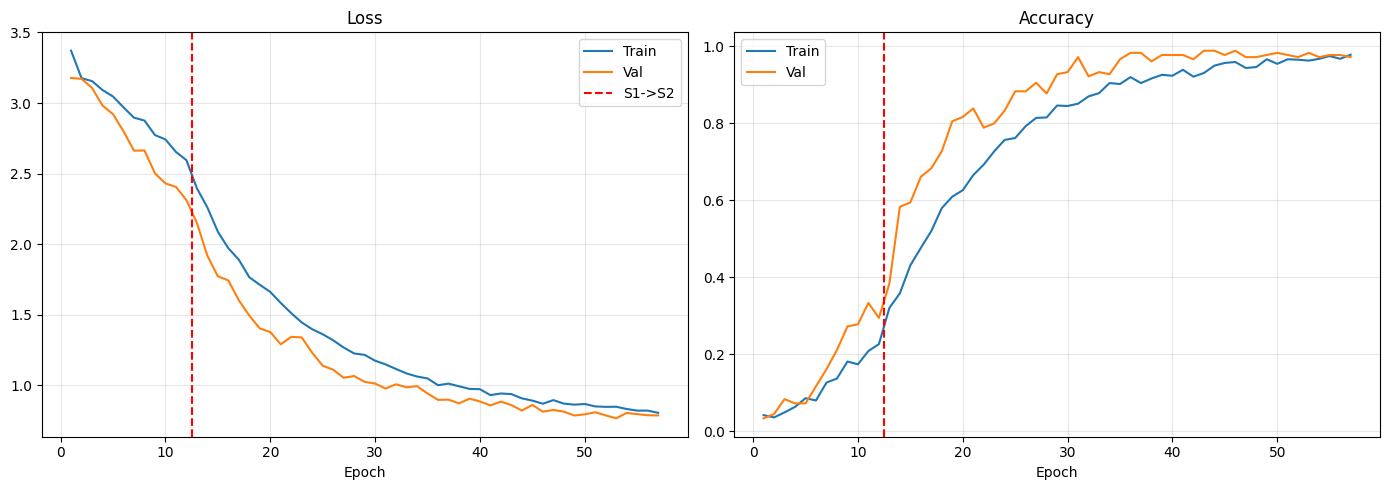

[Plot] Saved: /home/muji/skripsi_bisindo24/v10_lighting/training_history_v10.png


In [20]:
plot_history(h1, h2, os.path.join(SAVE_DIR, 'training_history_v10.png'))

## 11. Evaluasi test

In [21]:
print('=' * 60 + '\nFINAL TEST EVALUATION\n' + '=' * 60)
for ckpt in [CKPT_S2, CKPT_S1]:
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=device))
        print(f'Bobot dimuat: {ckpt}'); break
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, lb, _ in tqdm(test_loader, desc='Test'):
        inputs = inputs.to(device)
        probs = F.softmax(model(inputs), dim=1)
        all_probs.append(probs.cpu())
        all_preds.extend(probs.argmax(1).cpu().tolist())
        all_labels.extend(lb.tolist())
all_probs = torch.cat(all_probs).numpy()

test_acc    = np.mean(np.array(all_preds) == np.array(all_labels))
macro_f1    = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
print(f'\n--- METRICS ---\n  Top-1 Acc : {test_acc:.4f}\n'
      f'  Macro F1  : {macro_f1:.4f}\n  Weighted F1: {weighted_f1:.4f}')
print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(all_labels, all_preds,
                            target_names=EXPLICIT_CLASSES, digits=4))

FINAL TEST EVALUATION
Bobot dimuat: /home/muji/skripsi_bisindo24/v10_lighting/best_stage2_v10.pth


Test: 100%|██████████| 23/23 [00:47<00:00,  2.07s/it]


--- METRICS ---
  Top-1 Acc : 0.9722
  Macro F1  : 0.9725
  Weighted F1: 0.9718

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         air     1.0000    1.0000    1.0000         7
   bagaimana     1.0000    1.0000    1.0000         7
     belajar     1.0000    1.0000    1.0000         7
   berangkat     1.0000    0.7500    0.8571         8
        cari     1.0000    0.8750    0.9333         8
      datang     1.0000    1.0000    1.0000         7
      dengar     1.0000    0.8750    0.9333         8
      dimana     1.0000    1.0000    1.0000         8
       hijau     1.0000    1.0000    1.0000         7
       merah     1.0000    1.0000    1.0000         7
       kapan     1.0000    1.0000    1.0000         8
    keluarga     1.0000    1.0000    1.0000         7
      kuning     0.8750    1.0000    0.9333         7
        lagi     0.8750    1.0000    0.9333         7
        maaf     1.0000    1.0000    1.0000         8
       makan     0.8889

## 12. Confusion matrix

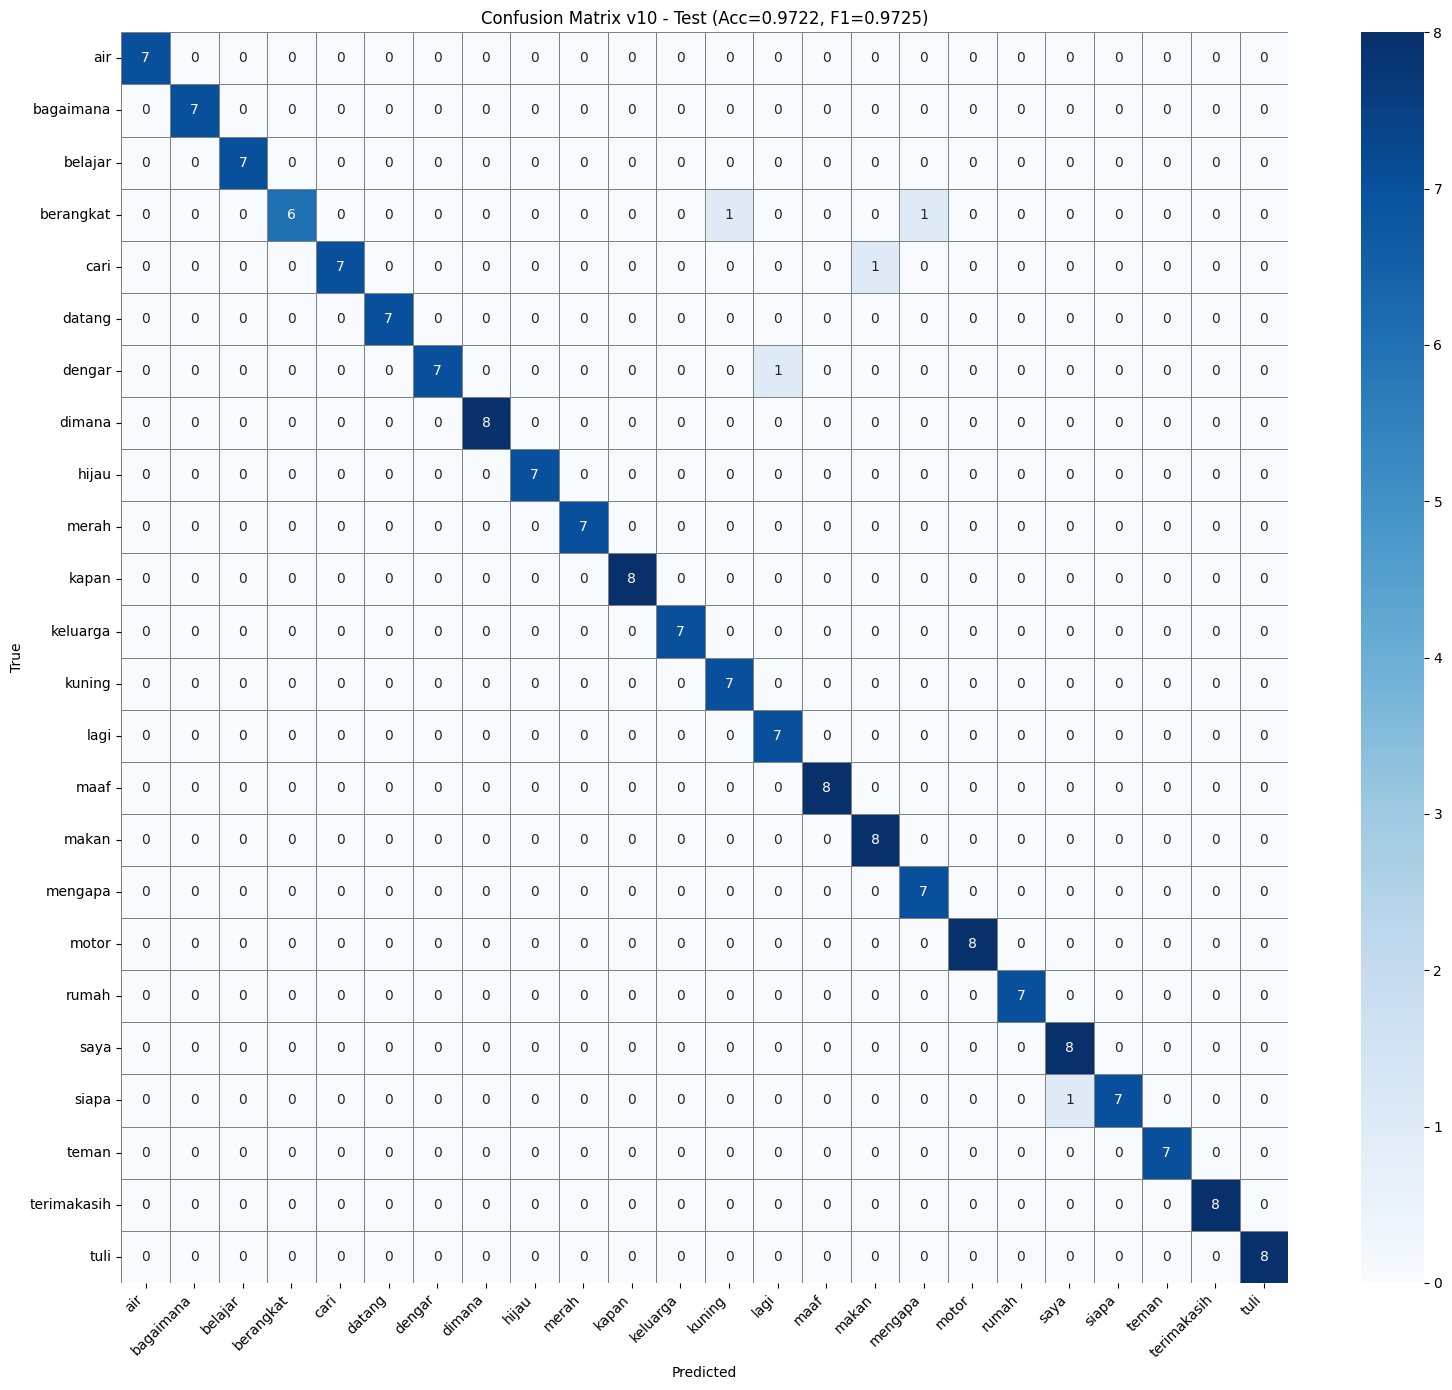

[CM] Saved: /home/muji/skripsi_bisindo24/v10_lighting/confusion_matrix_test_v10.png


In [22]:
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EXPLICIT_CLASSES, yticklabels=EXPLICIT_CLASSES,
            linewidths=0.5, linecolor='gray')
plt.title(f'Confusion Matrix v10 - Test (Acc={test_acc:.4f}, F1={macro_f1:.4f})')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, 'confusion_matrix_test_v10.png')
plt.savefig(cm_path, dpi=140, bbox_inches='tight')
plt.show()
print(f'[CM] Saved: {cm_path}')

## 13. Simpan checkpoint + metadata

In [23]:
ckpt_path = os.path.join(SAVE_DIR, 'bisindo_24_v10_checkpoint.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'classes': EXPLICIT_CLASSES, 'num_frames': NUM_FRAMES,
    'num_classes': NUM_CLASSES,
    'history_stage1': h1, 'history_stage2': h2,
    'test_metrics': {'accuracy': float(test_acc),
                     'macro_f1': float(macro_f1),
                     'weighted_f1': float(weighted_f1)},
    'config': {'dropout': DROPOUT, 'margin': MARGIN,
               'augment': 'spatial=v9, photometric=strong+gamma (v10)',
               'dataset': 'selfie-segmented'},
}, ckpt_path)
print(f'[Checkpoint] Saved: {ckpt_path}')
print('\n[SELESAI] Pindahkan best_stage2_v10.pth ke folder app untuk inference.')

[Checkpoint] Saved: /home/muji/skripsi_bisindo24/v10_lighting/bisindo_24_v10_checkpoint.pth

[SELESAI] Pindahkan best_stage2_v10.pth ke folder app untuk inference.
